# **Deep Learning based Models for Bitcoin Price Prediction Using Historical Market Data**

Data Fetching using `yfinance` for real time data

## **Libraries**

In [ ]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

warnings.filterwarnings('ignore')

## **Data Fetching**

**Bitcoin Prices for last 2 Year**

In [ ]:
ticker = "BTC-USD"

btc = yf.Ticker(ticker)

print("Fetching Daily prices from last 2 year\n")
btc_daily_data = btc.history(period='2y', interval='1d')

print("Daily Data (Last 2 Year)")
btc_daily_data.tail()

Fetching Daily prices from last 2 year

Daily Data (Last 2 Year)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-04-03 00:00:00+00:00,66889.015625,67296.234375,66281.539062,66931.101562,22815543346,0.0,0.0
2026-04-04 00:00:00+00:00,66938.648438,67515.015625,66769.640625,67290.515625,15878814963,0.0,0.0
2026-04-05 00:00:00+00:00,67291.195312,69087.656250,66610.632812,68981.898438,22972648674,0.0,0.0
2026-04-06 00:00:00+00:00,68982.914062,70305.421875,68347.078125,68859.828125,39542143229,0.0,0.0
2026-04-07 00:00:00+00:00,68860.460938,69193.554688,68162.187500,68368.242188,33226725376,0.0,0.0


In [ ]:
btc_daily_data.shape

(731, 7)

**Converting to csv**

In [ ]:
os.makedirs("bitcoin_price_data", exist_ok=True)
btc_daily_data.to_csv("bitcoin_price_data/btc_daily_2year.csv")

## **Preprocessing**

In [ ]:
btc_daily_data = pd.read_csv("bitcoin_price_data/btc_daily_2year.csv")
btc_daily_data.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
726,2026-04-03 00:00:00+00:00,66889.015625,67296.234375,66281.539062,66931.101562,22815543346,0.0,0.0
727,2026-04-04 00:00:00+00:00,66938.648438,67515.015625,66769.640625,67290.515625,15878814963,0.0,0.0
728,2026-04-05 00:00:00+00:00,67291.195312,69087.656250,66610.632812,68981.898438,22972648674,0.0,0.0
729,2026-04-06 00:00:00+00:00,68982.914062,70305.421875,68347.078125,68859.828125,39542143229,0.0,0.0
730,2026-04-07 00:00:00+00:00,68860.460938,69193.554688,68162.187500,68368.242188,33226725376,0.0,0.0


**Daily Data Preprocessing**

In [ ]:
btc_daily_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='object')

In [ ]:
btc_daily_data["Target"] = btc_daily_data["Close"].shift(-1)

In [ ]:
# Keeping only required data

btc_daily_data.drop(['Stock Splits', 'Dividends'], axis=1, inplace=True)
btc_daily_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target'], dtype='object')

In [ ]:
# Date Processing

btc_daily_data['Date'] = pd.to_datetime(btc_daily_data['Date'], utc=True).dt.date
btc_daily_data.tail()

,Date,Open,High,Low,Close,Volume,Target
726,2026-04-03,66889.015625,67296.234375,66281.539062,66931.101562,22815543346,67290.515625
727,2026-04-04,66938.648438,67515.015625,66769.640625,67290.515625,15878814963,68981.898438
728,2026-04-05,67291.195312,69087.656250,66610.632812,68981.898438,22972648674,68859.828125
729,2026-04-06,68982.914062,70305.421875,68347.078125,68859.828125,39542143229,68368.242188
730,2026-04-07,68860.460938,69193.554688,68162.187500,68368.242188,33226725376,NaN


## **EDA**

#### **Daily Data**

**Line Plot**

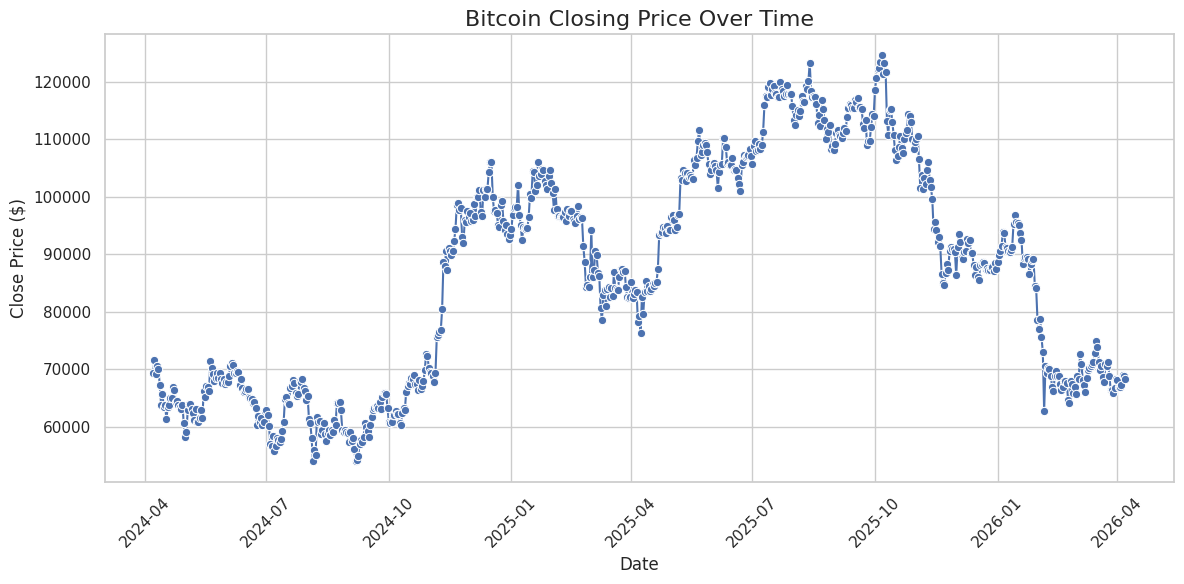

In [ ]:
btc_daily_data['Date'] = pd.to_datetime(btc_daily_data['Date'])

# 2. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 3. Create the line plot
line_plot = sns.lineplot(data=btc_daily_data, x='Date', y='Close', marker='o', color='b')

# 4. Customizing labels and title
plt.title('Bitcoin Closing Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price ($)', fontsize=12)

# Rotate dates for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Candle Stick Chart**

In [ ]:
import plotly.graph_objects as go

# 2. Create the Candlestick figure
fig = go.Figure(data=[go.Candlestick(
    x=btc_daily_data['Date'],
    open=btc_daily_data['Open'],
    high=btc_daily_data['High'],
    low=btc_daily_data['Low'],
    close=btc_daily_data['Close'],
    increasing_line_color='green',
    decreasing_line_color='red'
)])

# 3. Customize layout
fig.update_layout(
    title='Bitcoin Candlestick Chart',
    yaxis_title='Price (USD)',
    xaxis_title='Date',
    xaxis_rangeslider_visible=True,
    template='plotly_white'
)

# 4. Show the plot
fig.show()

**Correlation Heatmap**

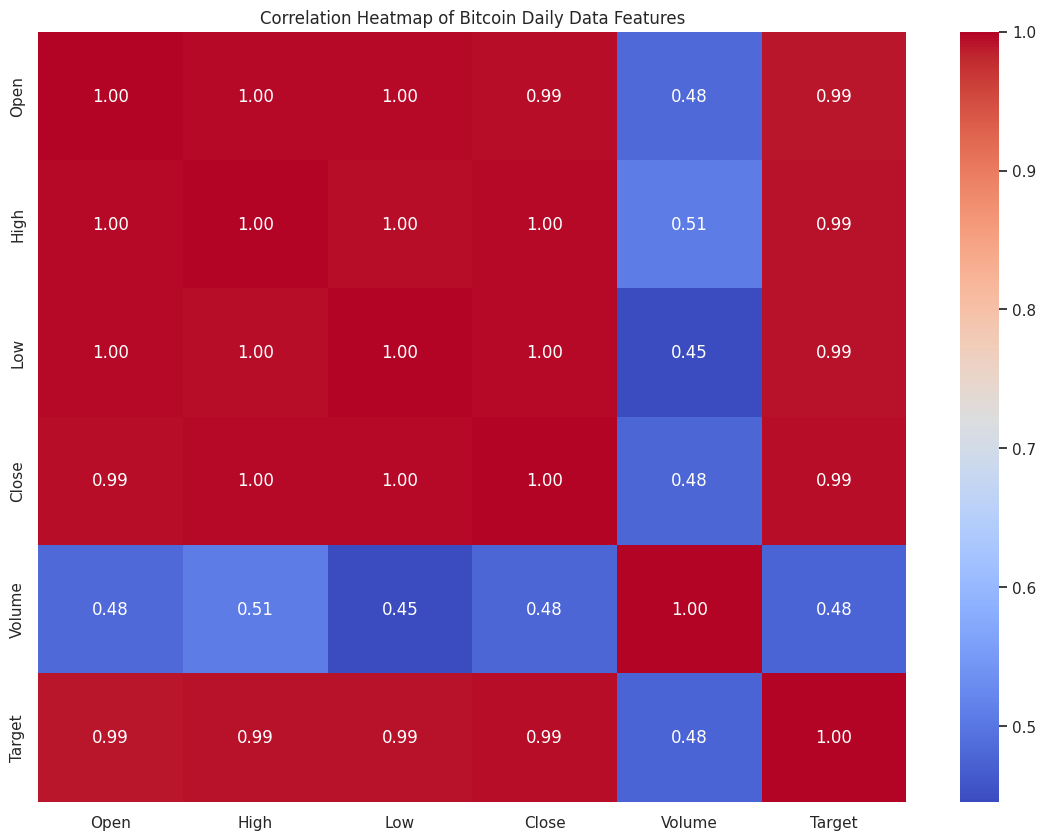

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(btc_daily_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Bitcoin Daily Data Features')
plt.show()

**Distribution of Close Prices**

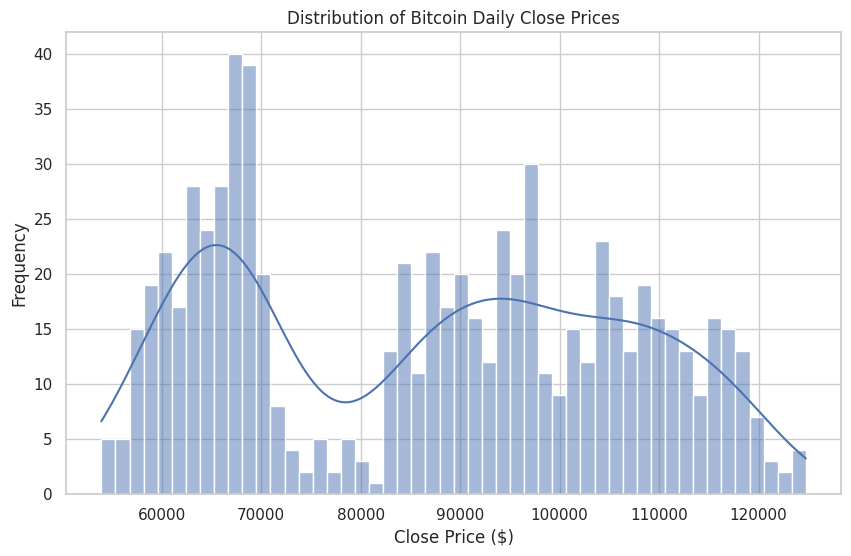

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(btc_daily_data['Close'], kde=True, bins=50)
plt.title('Distribution of Bitcoin Daily Close Prices')
plt.xlabel('Close Price ($)')
plt.ylabel('Frequency')
plt.show()

**Box Plot of Volume**

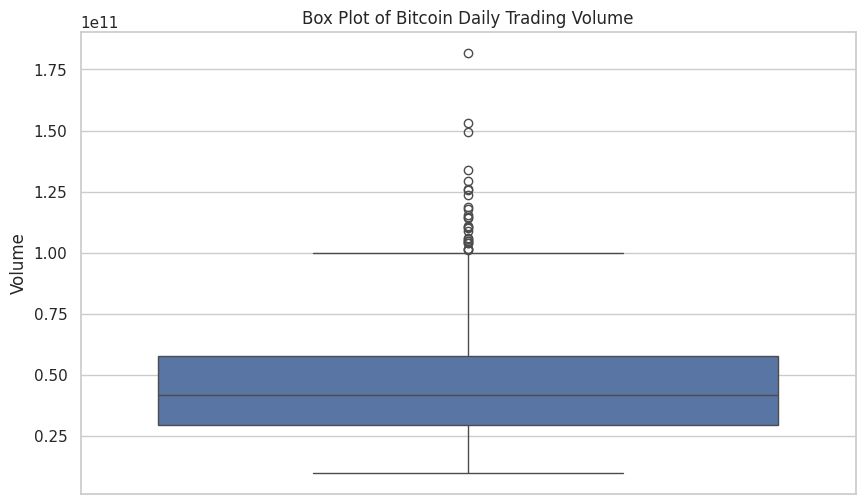

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=btc_daily_data['Volume'])
plt.title('Box Plot of Bitcoin Daily Trading Volume')
plt.ylabel('Volume')
plt.show()

In [ ]:
btc_daily_data.describe()

,Date,Open,High,Low,Close,Volume,Target
count,731,731.000000,731.000000,731.000000,731.000000,7.310000e+02,730.000000
mean,2025-04-07 00:00:00,86622.707159,88090.144414,85045.773299,86622.134645,4.637841e+10,86645.777906
min,2024-04-07 00:00:00,53949.085938,54838.144531,49121.238281,53948.753906,9.858199e+09,53948.753906
25%,2024-10-06 12:00:00,67390.742188,68457.246094,66259.578125,67383.843750,2.943033e+10,67375.847656
50%,2025-04-07 00:00:00,88344.703125,90267.460938,86717.914062,88344.000000,4.171957e+10,88387.066406
75%,2025-10-06 12:00:00,103722.496094,105397.570312,101491.984375,103723.925781,5.781190e+10,103734.283203
max,2026-04-07 00:00:00,124752.140625,126198.070312,123196.046875,124752.531250,1.817464e+11,124752.531250
std,NaN,19463.440399,19568.343357,19331.817939,19464.183651,2.392814e+10,19467.021948


## **Feature Engineering**

In [ ]:
# Price movement
btc_daily_data["Return"] = btc_daily_data["Close"].pct_change()

# Daily range (volatility proxy)
btc_daily_data["Range"] = btc_daily_data["High"] - btc_daily_data["Low"]

# Rolling averages
btc_daily_data["7_day_MA"] = btc_daily_data["Close"].rolling(7).mean()
btc_daily_data["14_day_MA"] = btc_daily_data["Close"].rolling(14).mean()
btc_daily_data["30_day_MA"] = btc_daily_data["Close"].rolling(30).mean()

# Rolling standard deviation (volatility)
btc_daily_data["7_day_Volatility"] = btc_daily_data["Close"].rolling(7).std()
btc_daily_data["30_day_Volatility"] = btc_daily_data["Close"].rolling(30).std()

# Momentum
btc_daily_data["7_day_Momentum"] = btc_daily_data["Close"] - btc_daily_data["Close"].shift(7)

# Lag features
btc_daily_data["Lag_1"] = btc_daily_data["Close"].shift(1)
btc_daily_data["Lag_2"] = btc_daily_data["Close"].shift(2)
btc_daily_data["Lag_3"] = btc_daily_data["Close"].shift(3)
btc_daily_data["Lag_7"] = btc_daily_data["Close"].shift(7)

**Rolling Mean**

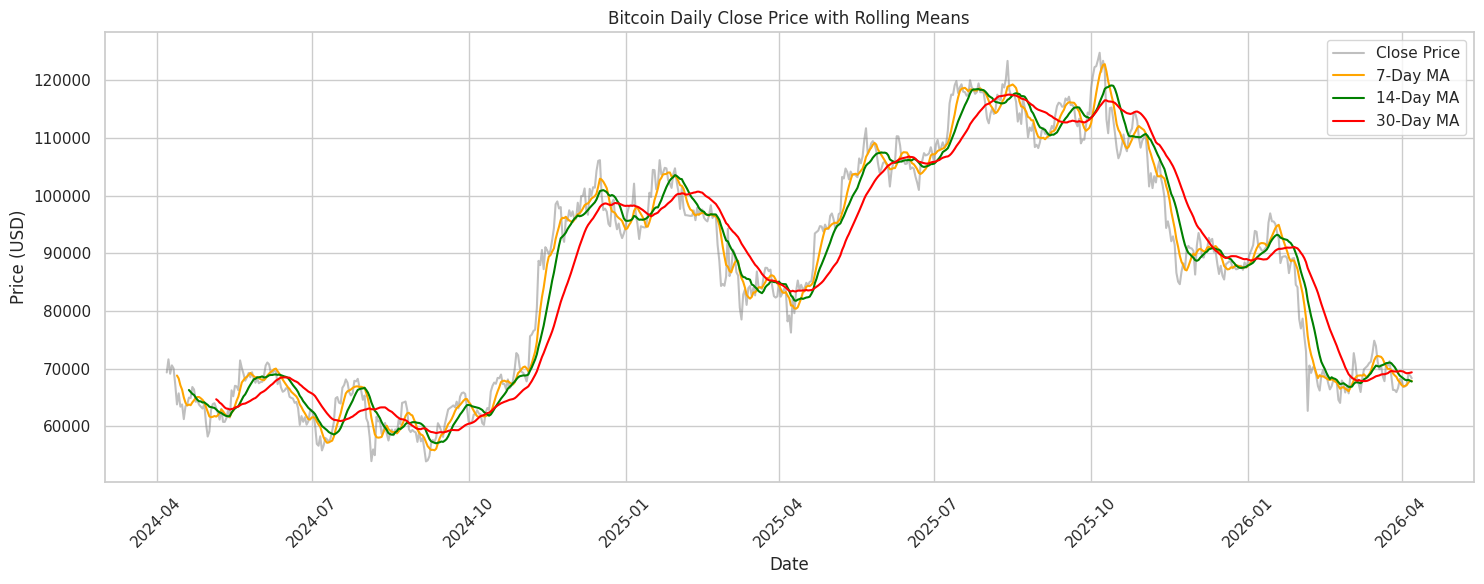

In [ ]:
# Plot Rolling Means
plt.figure(figsize=(15, 6))
plt.plot(btc_daily_data['Date'], btc_daily_data['Close'], label='Close Price', color='gray', alpha=0.5)
plt.plot(btc_daily_data['Date'], btc_daily_data['7_day_MA'], label='7-Day MA', color='orange')
plt.plot(btc_daily_data['Date'], btc_daily_data['14_day_MA'], label='14-Day MA', color='green')
plt.plot(btc_daily_data['Date'], btc_daily_data['30_day_MA'], label='30-Day MA', color='red')
plt.title('Bitcoin Daily Close Price with Rolling Means')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Rolling Volatility**

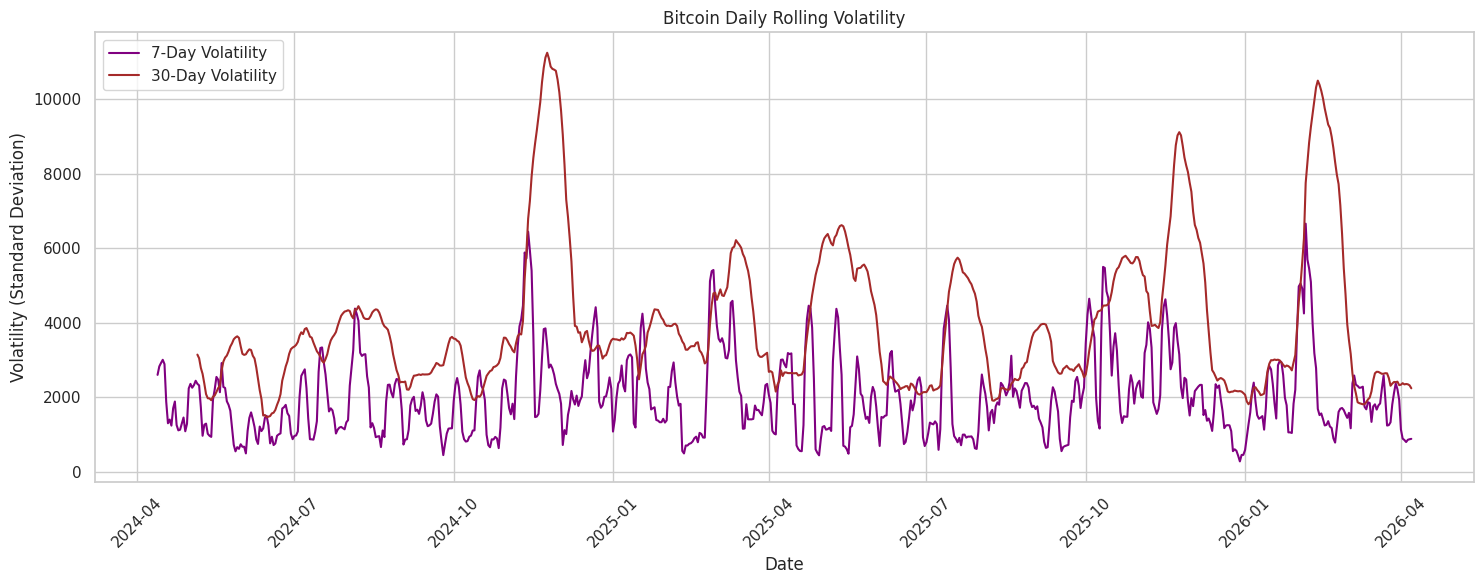

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(btc_daily_data['Date'], btc_daily_data['7_day_Volatility'], label='7-Day Volatility', color='purple')
plt.plot(btc_daily_data['Date'], btc_daily_data['30_day_Volatility'], label='30-Day Volatility', color='brown')
plt.title('Bitcoin Daily Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
btc_daily_data.tail()

,Date,Open,High,Low,Close,Volume,Target,Return,Range,7_day_MA,14_day_MA,30_day_MA,7_day_Volatility,30_day_Volatility,7_day_Momentum,Lag_1,Lag_2,Lag_3,Lag_7
726,2026-04-03,66889.015625,67296.234375,66281.539062,66931.101562,22815543346,67290.515625,0.000636,1014.695312,67013.943080,68109.066964,69340.396615,851.503708,2344.877611,592.726562,66888.570312,68078.554688,68233.312500,66338.375000
727,2026-04-04,66938.648438,67515.015625,66769.640625,67290.515625,15878814963,68981.898438,0.005370,745.375000,67152.631696,68007.566406,69222.042969,796.892096,2356.097578,970.820312,66931.101562,66888.570312,68078.554688,66319.695312
728,2026-04-05,67291.195312,69087.656250,66610.632812,68981.898438,22972648674,68859.828125,0.025136,2477.023438,67585.056920,68088.758371,69250.223177,857.611903,2347.706902,3026.976562,67290.515625,66931.101562,66888.570312,65954.921875
729,2026-04-06,68982.914062,70305.421875,68347.078125,68859.828125,39542143229,68368.242188,-0.001770,1958.343750,67894.825893,67941.970424,69303.130990,872.524236,2319.315567,2168.382812,68981.898438,67290.515625,66931.101562,66691.445312
730,2026-04-07,68860.460938,69193.554688,68162.187500,68368.242188,33226725376,NaN,-0.007139,1031.367188,67914.101562,67788.426339,69383.079687,882.679651,2240.447608,134.929688,68859.828125,68981.898438,67290.515625,68233.312500


In [ ]:
btc_daily_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target', 'Return',
       'Range', '7_day_MA', '14_day_MA', '30_day_MA', '7_day_Volatility',
       '30_day_Volatility', '7_day_Momentum', 'Lag_1', 'Lag_2', 'Lag_3',
       'Lag_7'],
      dtype='object')